In [63]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [64]:
#задача состоит в выявлении аномалий в датасете и удаления их из него для дальнейшего анализа
#но так же необходимо определить что вообще будем называть аномалиями 
#в задании есть пометка что аномалиями могут быть названы ситуации с подозрительной активностью ,которая не соответсвует 
#обычному поведению пользователей,но что назовем обычным и необычным поведением пользователя?


In [65]:
#проанализируем данные которые лежат в датасете

In [66]:
DF=pd.read_csv('views_statistics.csv')
DF

,time,user_id,ip,video_id,platform
0,2025-02-20 00:00:00.000,1964,115.140.58.148,18318,android
1,2025-02-20 00:00:00.750,1573,160.179.46.24,13693,android
2,2025-02-20 00:00:02.750,2223,228.214.166.91,84713,android
3,2025-02-20 00:00:05.750,1126,184.57.115.70,35616,iphone
4,2025-02-20 00:00:07.750,26,172.10.12.34,34873,android
...,...,...,...,...,...
80337,2025-02-20 23:59:48.000,1248,142.44.157.53,51942,iphone
80338,2025-02-20 23:59:49.500,1627,135.198.71.195,87627,android
80339,2025-02-20 23:59:53.750,1001,127.1.203.10,12916,iphone
80340,2025-02-20 23:59:58.000,494,244.206.196.177,55617,iphone


In [67]:
DF['time']=pd.to_datetime(DF['time'])
DF['date']=DF['time'].dt.date
DF['time']=DF['time'].dt.time
DF

,time,user_id,ip,video_id,platform,date
0,00:00:00,1964,115.140.58.148,18318,android,2025-02-20
1,00:00:00.750000,1573,160.179.46.24,13693,android,2025-02-20
2,00:00:02.750000,2223,228.214.166.91,84713,android,2025-02-20
3,00:00:05.750000,1126,184.57.115.70,35616,iphone,2025-02-20
4,00:00:07.750000,26,172.10.12.34,34873,android,2025-02-20
...,...,...,...,...,...,...
80337,23:59:48,1248,142.44.157.53,51942,iphone,2025-02-20
80338,23:59:49.500000,1627,135.198.71.195,87627,android,2025-02-20
80339,23:59:53.750000,1001,127.1.203.10,12916,iphone,2025-02-20
80340,23:59:58,494,244.206.196.177,55617,iphone,2025-02-20


In [68]:
DF['date'].unique() #рассматриваем информацию за 1 день,а именно за 20 февраля 2025г(четверг)

array([datetime.date(2025, 2, 20)], dtype=object)

In [69]:
len(DF['user_id'].unique()) #кол-во пользователи которые просматрели видео

2412

In [70]:
len(DF['video_id'].unique())#кол-во просмотренных видео за день 

150

In [71]:
DF.isna().sum()#просмотр NULL значений
# видим , что таких атрибутов нет

time        0
user_id     0
ip          0
video_id    0
platform    0
date        0
dtype: int64

In [72]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80342 entries, 0 to 80341
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   time      80342 non-null  object
 1   user_id   80342 non-null  int64 
 2   ip        80342 non-null  object
 3   video_id  80342 non-null  int64 
 4   platform  80342 non-null  object
 5   date      80342 non-null  object
dtypes: int64(2), object(4)
memory usage: 3.7+ MB


In [73]:
#таким образом имеем данные о просмотрах видео за 20 февраля 2025г, 
#2412 уникальных пользователей и 150 видео были просмотрены на платформе за этот день 

In [74]:
#посмотрим сколько видео каждый пользователь посмотрел за этот день
data=DF.groupby('user_id').agg(count_views=('video_id','count')).reset_index().sort_values(by='count_views',ascending=False)
data

,user_id,count_views
2411,3452,2830
730,731,51
1035,1036,51
1257,1258,49
941,942,49
...,...,...
530,531,16
1,2,15
1834,1835,15
794,795,15


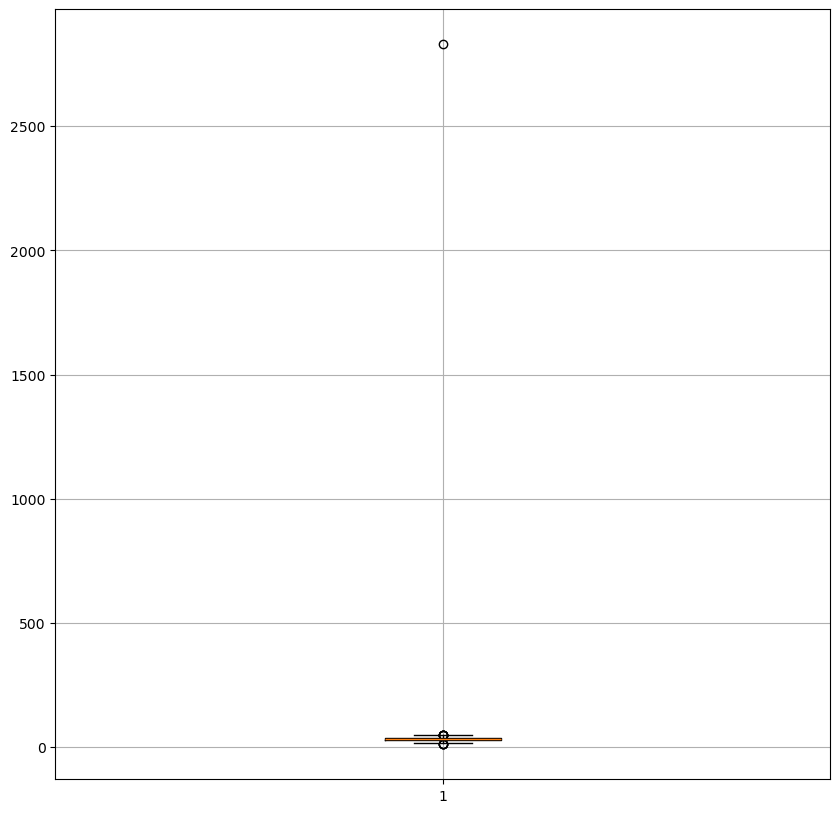

In [75]:
plt.figure(figsize=(10,10))
plt.boxplot(x=data['count_views'])
plt.grid()
plt.show()

In [76]:
#видим что есть значительный выброс в просмотренных пользователем видео 

In [77]:
#необходимо понять что будем называть обычным поведением пользователя на платформе,а что связывать с ботами ,
#аккаунтами для накрутки(подозрительная активность)

#мы должны понимать что видео может быть просмотрены несолкьо раз настоящим пользователем по некоторым причиным 
# 1) необходимо пересмотреть видео
# 2) отошел по делам и остановился на этом видео 


# так же есть боты,аккаунты накрутку 

#проанализируем какие аккаунты будем считать "настоящим пользователем" "ботом" исходя из кол-во сколько раз пользователь
#пересмотрел 1 видео раз

In [78]:
#рассмотрим сколько раз i пользователь посмотрел j видео 
revision=DF.groupby(['user_id','video_id']).agg(count_views=('video_id','count')).reset_index().sort_values(by='user_id',ascending=False)
revision

,user_id,video_id,count_views
67189,3452,60563,2830
67174,2411,58204,1
67159,2411,11527,1
67160,2411,12078,3
67161,2411,12916,1
...,...,...,...
4,5,12468,28
3,4,12468,19
2,3,12468,20
1,2,12468,15


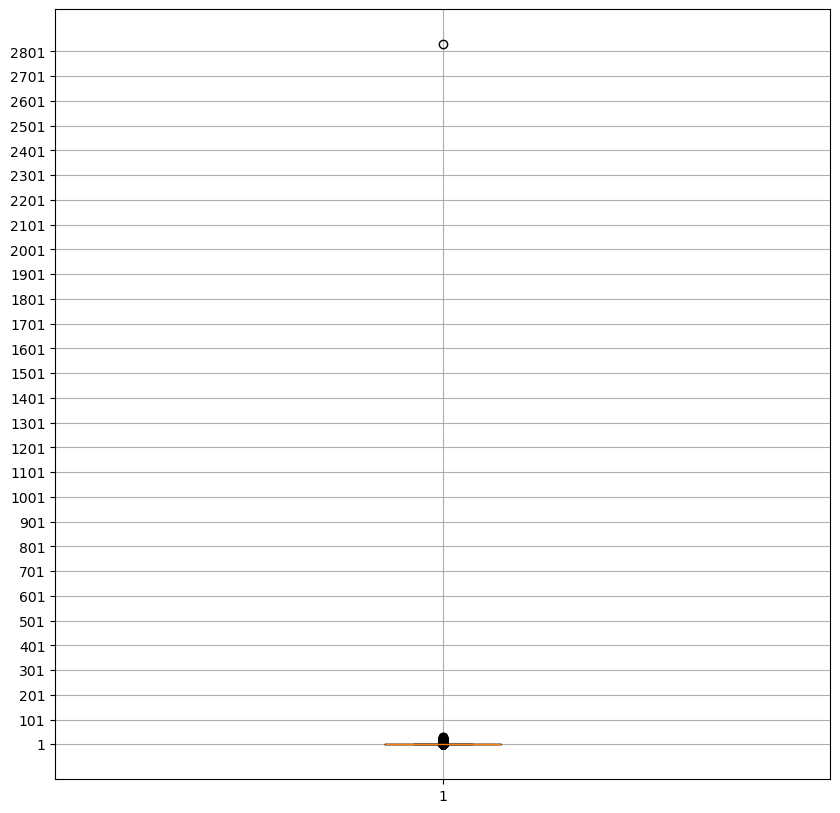

In [79]:
plt.figure(figsize=(10,10))
plt.boxplot(x=revision['count_views'])
plt.yticks(np.arange(min(revision['count_views']),max(revision['count_views']),100))
plt.grid()
plt.show()

In [80]:
#видим что есть значительный выброс просмотра 1 пользователем 1 видео 
#это пользователь(3452) просмотрел видео(60563) 2830 раз

In [81]:
#посмотрим пользавлятель с user_id 3452 подробнее
data_3452=DF.query(f'user_id == 3452')

In [82]:
data_3452

,time,user_id,ip,video_id,platform,date
22707,10:42:23.750000,3452,44.68.82.175,60563,iphone,2025-02-20
22708,10:42:23.750000,3452,44.68.82.175,60563,android,2025-02-20
22711,10:42:24.750000,3452,44.68.82.175,60563,iphone,2025-02-20
22712,10:42:25,3452,44.68.82.175,60563,android,2025-02-20
22713,10:42:25.250000,3452,44.68.82.175,60563,android,2025-02-20
...,...,...,...,...,...,...
26557,10:58:09,3452,44.68.82.175,60563,android,2025-02-20
26561,10:58:10.750000,3452,44.68.82.175,60563,iphone,2025-02-20
26562,10:58:11,3452,44.68.82.175,60563,iphone,2025-02-20
26564,10:58:11.250000,3452,44.68.82.175,60563,iphone,2025-02-20


In [84]:
data_3452.groupby('platform').agg(count_phone=('user_id','count')).reset_index()

,platform,count_phone
0,android,1444
1,iphone,1386


In [85]:
data_3452['video_id'].unique()#видим что пользователь просмотрел лишь одно видео(60563) c 2 устройств 

array([60563])

In [86]:
#видим что есть 2 платформы откуда был совершен вход то есть 2 устройства,один user_id и один ip
#то есть с 2 устройств был сделан вход в один аккаунт + 
# эти 2 устройства находятся в одной локальной сети ,
# времянной интервал за который были совершены просмотры [10:42:23.750000;10:58:11.750000]
# то есть за 16 минут видео 60563 было просмотрено 2830 раз c одного аккаута и из одной локальной сети 
#что можно расценить как аккаунт для накрутки просмотров или бота 
#является явной аномалией удалим этого пользователя с датасета
#что позволит нам лучше оценить другие данные

In [87]:
DF.drop(index=data_3452.index,inplace=True)

In [88]:
DF

,time,user_id,ip,video_id,platform,date
0,00:00:00,1964,115.140.58.148,18318,android,2025-02-20
1,00:00:00.750000,1573,160.179.46.24,13693,android,2025-02-20
2,00:00:02.750000,2223,228.214.166.91,84713,android,2025-02-20
3,00:00:05.750000,1126,184.57.115.70,35616,iphone,2025-02-20
4,00:00:07.750000,26,172.10.12.34,34873,android,2025-02-20
...,...,...,...,...,...,...
80337,23:59:48,1248,142.44.157.53,51942,iphone,2025-02-20
80338,23:59:49.500000,1627,135.198.71.195,87627,android,2025-02-20
80339,23:59:53.750000,1001,127.1.203.10,12916,iphone,2025-02-20
80340,23:59:58,494,244.206.196.177,55617,iphone,2025-02-20


In [89]:
revision=DF.groupby(['video_id','user_id']).agg(count_views=('user_id','count')).reset_index().\
            sort_values(by='count_views',ascending=False)

revision.groupby('count_views').agg(count=('user_id','count')).reset_index()#группировка по кол-ву просмотров

,count_views,count
0,1,58281
1,2,7977
2,3,828
3,4,80
4,5,2
5,12,1
6,15,1
7,16,1
8,18,1
9,19,2


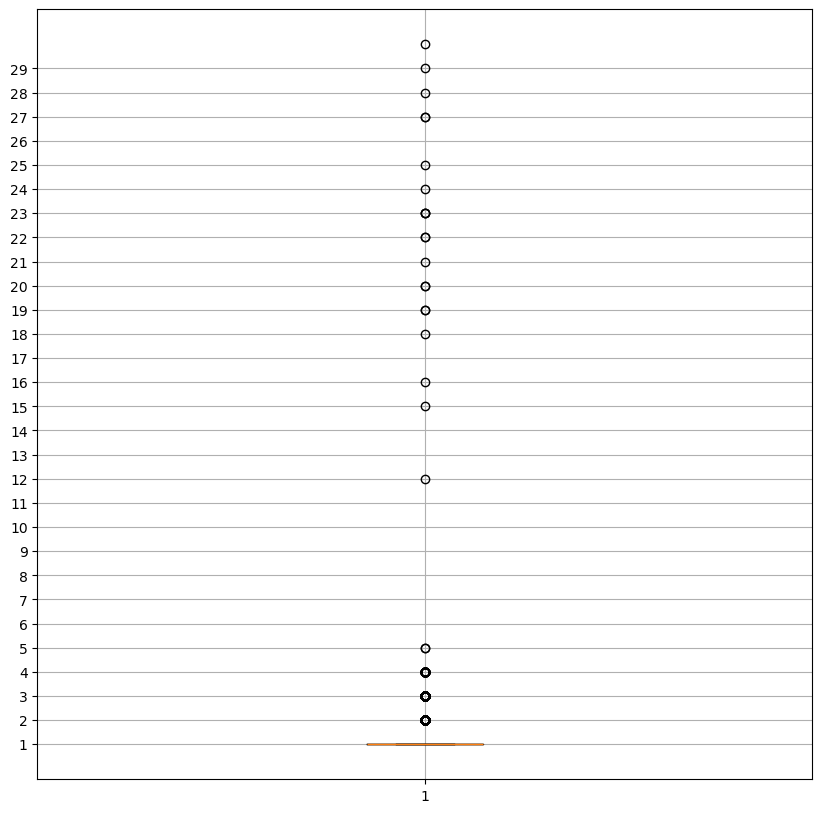

In [90]:
plt.figure(figsize=(10,10))
plt.boxplot(x=revision['count_views'])
plt.yticks(np.arange(min(revision['count_views']),max(revision['count_views']),1))
plt.grid()
plt.show()

In [91]:
revision['count_views'].describe()

count    67189.000000
mean         1.153641
std          0.548328
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         30.000000
Name: count_views, dtype: float64

In [95]:
# какие можем сделать выводы 
# большая часть пользователей а именно 75% просматривает видео лишь 1 раз 
# то есть в среднем каждый пользователь совершает  1.153641 просмотров 
# так же имеем небольшую дисперсию(0.548328) то есть данные близко сгруппированы к среднему значению
# максимальное значение 30 при том что среднее немного больше 1 то есть имеются выбросы
# что и видим по графику boxplot все значения не равные 1 приравниваются к выбросам,но 
#выбросы с кол-вом просмотров=  2,3,4 являются скоплением точек,то есть существуют группы пользователей 
#просматривающие видео 2,3,4 раза. 
# так же можем увидеть что кол-во просмотров резко увеличивается с 5 сразу на 12 просмотров 1 человеком 1 видео 


#что же делать с пользователями которые просмотрели 1 видео 5 раз их немного и не очень понятно к кому их отнести 
#рассмотрим таких пользователей подробнее

In [93]:
revision.query(f'count_views == 5')

,video_id,user_id,count_views
20459,32501,2284,5
546,11471,602,5


In [96]:
#просмотрим этих 1 из таких пользователей и поймем считать ли таких юзеров пользователями или ботами
DF.query(f'user_id == 2284').groupby('video_id').agg(count=('video_id','count'))
# видим что это типичный  пользователь который просмотрел 1 видео 5 раз 

,count
video_id,
10277,1
11527,1
12468,2
12787,1
13333,2
16651,2
17378,1
18318,1
21474,1


In [23]:
#тоже является обычным пользователем ,который по неизвестной причине просмотрел такое кол-во видео
DF.query(f'user_id == 602').groupby('video_id').agg(count=('video_id','count'))

,count
video_id,
11471,5
12078,1
13663,1
13693,1
15451,1
17284,1
18413,1
21474,1
21505,1


In [41]:
#ВЫВОД 
# всех пользователей просматревших 1 видео больше 5 раз(строго) будем считать ботами или аккаунтами для накрутки (не типичное пведение)

In [151]:
#рассмотрим другие выбросы,может быть среди них тоже есть пользователи 

In [97]:
bots=revision.query('count_views in [12,15,16,18,19,20,21,22,23,24,25,27,28,29,30]')
bots
#видим что все просмотры юзеров лишь направлены на 1 видео 12468 и других просмотров у них нет 

,video_id,user_id,count_views
2821,12468,20,30
2816,12468,15,29
2806,12468,5,28
2813,12468,12,27
2818,12468,17,27
2810,12468,9,25
2809,12468,8,24
2812,12468,11,23
2811,12468,10,23
2822,12468,21,23


In [55]:
index=DF[DF['user_id'].isin(bots['user_id'])]

In [56]:
index['ip'].unique()#у всех пользователей одинаковый ip(одна и та же локальная сеть)

array(['213.167.68.178'], dtype=object)

In [ ]:
#делаем соотвествующий вывод что это боты то есть подозрительная активность не соответствующая обычному пользователю

In [102]:
DF.drop(index=index.index,inplace=True)

In [105]:
DF.to_csv('answer.csv')